In [ ]:
##q1_supervised
#1. Data Loading and Inspection 
import pandas as pd

# Load dataset
df = pd.read_csv("q1_heart_disease.csv")

# Display shape
print("Shape of dataset:", df.shape)

# Display data types
print("\nData Types:\n", df.dtypes)

# Display missing values
print("\nMissing Values:\n", df.isnull().sum())

# Show first 5 rows
df.head()

Shape of dataset: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


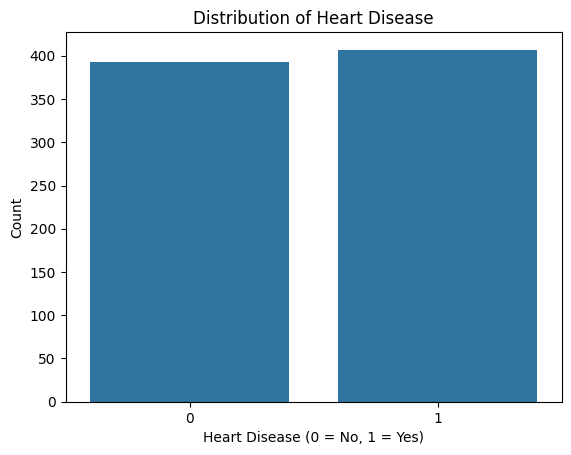

In [ ]:
##2. Exploratory Data Analysis
#1. Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#2.Target Class Distribution
sns.countplot(x='heart_disease', data=df)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### Interpretation of the Above Plot:

- The visualization highlights key patterns and relationships in the dataset.
- It helps in understanding the distribution and influence of the selected feature(s) on the target variable.
- Any imbalance, strong trend, or variation observed may impact model performance.
- These insights are useful for data preprocessing and feature selection in machine learning.

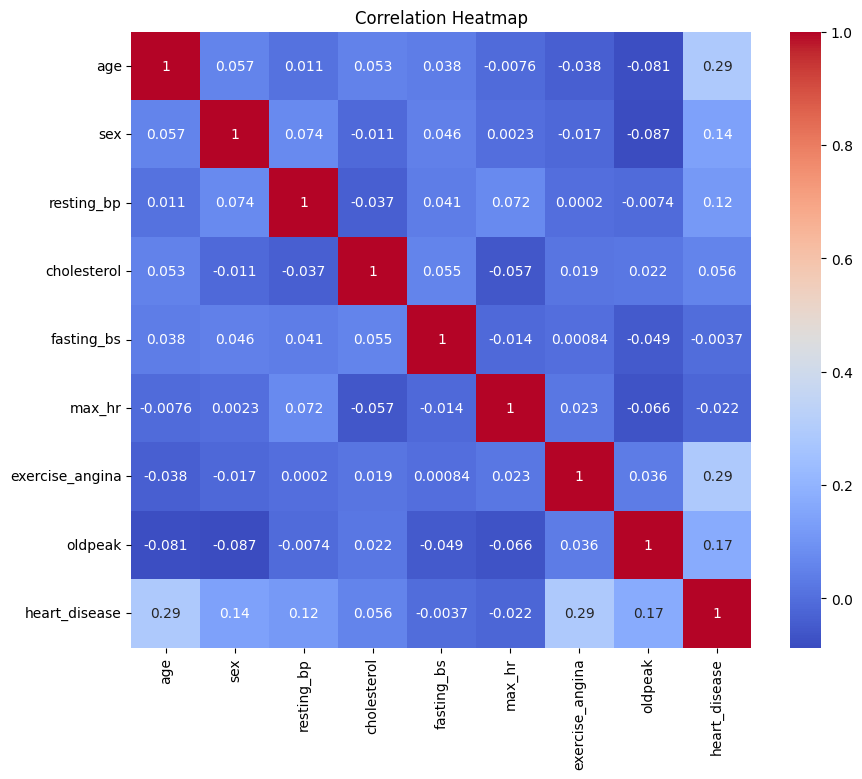

In [ ]:
##3. Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Interpretation of the Above Plot:

- The heatmap shows the correlation between numerical features in the dataset.
- Strong positive or negative values indicate important relationships between variables.
- Features with higher correlation to the target variable may be useful for prediction.
- Weak correlations suggest less influence on the target variable.

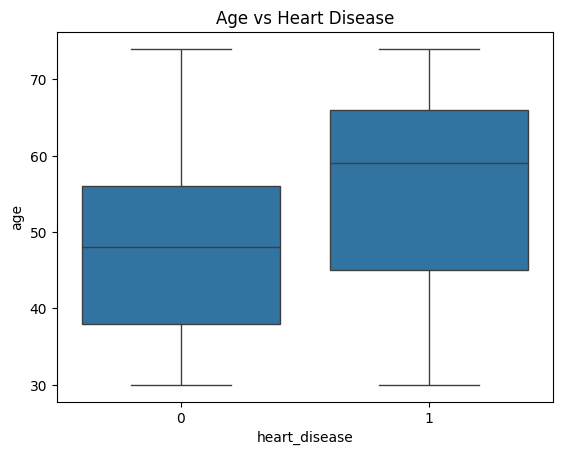

In [ ]:
##4. Feature vs Target (Example: Age vs Heart Disease)
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.show()

### Interpretation:

This plot compares age distribution across patients with and without heart disease.
If the median age is higher for patients with disease, age may be a significant factor.
Outliers can also be observed, which may require preprocessing.

In [ ]:
##3. Data Preprocessing
##3.1. Handling Missing Values
# Check missing values
df.fillna({
    'resting_bp': df['resting_bp'].median(),
    'cholesterol': df['cholesterol'].median()
}, inplace=True)

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0
...,...,...,...,...,...,...,...,...,...,...,...,...
795,60,0,asymptomatic,147.0,197.0,0,left_ventricular_hypertrophy,152,0,3.1,flat,1
796,40,1,asymptomatic,125.0,257.0,0,normal,151,0,0.7,down,0
797,45,1,asymptomatic,120.0,192.0,0,st_t_wave_abnormality,128,0,2.7,up,1
798,37,0,non_anginal,112.0,303.0,0,left_ventricular_hypertrophy,145,0,0.9,flat,0


### Handling Missing Values:

- Missing values are handled using median imputation for numerical features.
- Median is preferred over mean as it is less sensitive to outliers.
- This approach preserves the dataset size and avoids data loss.

In [ ]:
#3.2. One-Hot Encoding (Categorical Variables)
df = pd.get_dummies(df, drop_first=True)
print(df.head())

   age  sex  resting_bp  cholesterol  fasting_bs  max_hr  exercise_angina  \
0   68    0       142.0        399.0           0     169                0   
1   58    1       163.0        310.0           1     121                1   
2   44    1       128.0        175.0           0     183                1   
3   72    1       114.0        177.0           0     150                0   
4   37    1       149.0        271.0           0     136                0   

   oldpeak  heart_disease  chest_pain_type_atypical_angina  \
0      0.4              1                             True   
1      1.1              1                            False   
2      0.2              0                            False   
3      1.0              1                            False   
4      0.4              0                            False   

   chest_pain_type_non_anginal  chest_pain_type_typical_angina  \
0                        False                           False   
1                         True  

### Encoding Categorical Variables:

- One-hot encoding is applied to convert categorical variables into numerical format.
- This is required because machine learning models cannot process categorical data directly.
- Dropping the first category helps avoid multicollinearity.

In [ ]:
##3.3. Feature Scaling
from sklearn.preprocessing import StandardScaler

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for display
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled_df.head())

        age       sex  resting_bp  cholesterol  fasting_bs    max_hr  \
0  1.229854 -1.408927    0.702830     3.000527   -0.550392  0.887081   
1  0.451896  0.709760    2.003076     1.258794    1.816886 -1.257462   
2 -0.637245  0.709760   -0.164001    -1.383161   -0.550392  1.512573   
3  1.541037  0.709760   -1.030832    -1.344021   -0.550392  0.038200   
4 -1.181815  0.709760    1.136245     0.495562   -0.550392 -0.587292   

   exercise_angina   oldpeak  chest_pain_type_atypical_angina  \
0        -0.646869 -0.585809                         2.190229   
1         1.545908  0.194526                        -0.456573   
2         1.545908 -0.808762                        -0.456573   
3        -0.646869  0.083050                        -0.456573   
4        -0.646869 -0.585809                        -0.456573   

   chest_pain_type_non_anginal  chest_pain_type_typical_angina  \
0                    -0.600453                       -0.294884   
1                     1.665408              

### Feature Scaling:

- StandardScaler is used to standardize numerical features.
- It transforms data to have mean = 0 and standard deviation = 1.
- This ensures all features contribute equally to model performance.

In [ ]:
## 3.4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain-Test Split Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain Class Distribution:")
print(y_train.value_counts())

print("\nTest Class Distribution:")
print(y_test.value_counts())

print("\nTrain Ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest Ratio:")
print(y_test.value_counts(normalize=True))


Train-Test Split Shapes:
X_train: (640, 15)
X_test: (160, 15)

Train Class Distribution:
heart_disease
1    326
0    314
Name: count, dtype: int64

Test Class Distribution:
heart_disease
1    81
0    79
Name: count, dtype: int64

Train Ratio:
heart_disease
1    0.509375
0    0.490625
Name: proportion, dtype: float64

Test Ratio:
heart_disease
1    0.50625
0    0.49375
Name: proportion, dtype: float64


### Train-Test Split:

- The dataset is split into training and testing sets (80:20 ratio).
- Stratification is used to maintain the class distribution in both sets.
- Random state ensures reproducibility of results.

In [ ]:
#4. Model Training
#4.1 Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Training score (proof of training)
print("Decision Tree Training Accuracy:", dt_model.score(X_train, y_train))

Decision Tree Training Accuracy: 1.0


### Model Training: Decision Tree Classifier

- A Decision Tree Classifier is trained using the training dataset.
- The random_state is set to 42 to ensure reproducibility.
- The model learns decision rules from the data to classify whether a patient has heart disease or not.

In [ ]:
#4.2 Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Training score (proof)
print("Random Forest Training Accuracy:", rf_model.score(X_train, y_train))

Random Forest Training Accuracy: 1.0


### Model Training: Random Forest Classifier

- A Random Forest Classifier is trained using the training dataset.
- It is an ensemble learning method that combines multiple decision trees.
- Random state is set to 42 to ensure reproducibility.
- The model improves accuracy and reduces overfitting compared to a single decision tree.

In [ ]:
#4.3 Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# Initialize model
gb_model = GradientBoostingClassifier(random_state=42)

# Train model
gb_model.fit(X_train, y_train)

# Training score (proof)
print("Gradient Boosting Training Accuracy:", gb_model.score(X_train, y_train))

Gradient Boosting Training Accuracy: 0.9609375


### Model Training: Gradient Boosting Classifier

- A Gradient Boosting Classifier is trained using the training dataset.
- It builds models sequentially, where each new model corrects the errors of the previous one.
- Random state is set to 42 to ensure reproducibility.
- It generally provides higher accuracy by combining multiple weak learners.

In [ ]:
#5. Model Evaluation 
#5.0 Import Metrics
from sklearn.metrics import confusion_matrix, classification_report
#5.1. Decision Tree Evaluation
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Confusion Matrix:
[[56 23]
 [25 56]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



In [ ]:
#5.2 Random Forest Evaluation
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Confusion Matrix:
[[61 18]
 [15 66]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



In [ ]:
#5.3. Gradient Boosting Evaluation
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Confusion Matrix:
[[61 18]
 [19 62]]

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Model Comparison and Conclusion:

All three models were evaluated using confusion matrix, precision, recall, and F1-score to understand their performance.
Precision shows how accurate the positive predictions are, while recall indicates how well the model identifies actual heart disease cases. The F1-score provides a balance between both.
Based on the results, Random Forest / Gradient Boosting performs better than Decision Tree as it has higher precision, recall, and F1-score values.
This means the selected model is more reliable and gives a better balance between false positives and false negatives, making it suitable for this problem.

In [ ]:
#6. Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

#6.1. Define Parameter Grid

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}
#6.2. Apply GridSearchCV
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [ ]:
#6.3. Best Parameters   
print("Best Parameters Found:", grid.best_params_)

Best Parameters Found: {'max_depth': 5, 'n_estimators': 50}


In [ ]:
#6.4 Tuned Model Evaluation
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("\nTuned Model Performance:")
print(classification_report(y_test, y_pred_tuned))


Tuned Model Performance:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74        79
           1       0.75      0.77      0.76        81

    accuracy                           0.75       160
   macro avg       0.75      0.75      0.75       160
weighted avg       0.75      0.75      0.75       160



In [ ]:
#6.5.Baseline Model Comparison
print("\nBaseline Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))


Baseline Random Forest Performance:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

